In [1]:
# === Section 1: Setup & Imports ===
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')


from functions import load_subject_data, create_windows, stat_features, freq_features, eda_extra_features, extract_window_features

In [2]:
# === Constants ===
DATA_PATH = Path('WESAD')
SUBJECT_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
LABEL_MAP = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
WRIST_SAMPLING_RATES = {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}
LABEL_SAMPLING_RATE = 700
WINDOW_SIZE_SEC = 5  # 5-second windows
VALID_LABELS = [1, 2, 3]
# Binary mapping: 0 = Non-Stress (baseline + amusement), 1 = Stress
BINARY_MAP = {1: 0, 2: 1, 3: 0}
BINARY_LABEL_NAMES = ['Non-Stress', 'Stress']

print(f"Subjects: {SUBJECT_IDS}")
print(f"Window size: {WINDOW_SIZE_SEC}s")

Subjects: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
Window size: 5s


In [3]:
all_subjects_data = {}

for sid in SUBJECT_IDS:
    print(f"Loading S{sid}...", end=" ")
    all_subjects_data[sid] = load_subject_data(DATA_PATH, sid)
    print("OK")

print(f"\nLoaded {len(all_subjects_data)} subjects successfully.")

Loading S2... OK
Loading S3... OK
Loading S4... OK
Loading S5... OK
Loading S6... OK
Loading S7... OK
Loading S8... OK
Loading S9... OK
Loading S10... OK
Loading S11... OK
Loading S13... OK
Loading S14... OK
Loading S15... OK
Loading S16... OK
Loading S17... OK

Loaded 15 subjects successfully.


Section 2 — Data Loading & Exploration

In [4]:
# === Explore structure of one subject ===
sample = all_subjects_data[SUBJECT_IDS[0]]
print(f"Subject: {sample['subject']}")
print(f"Top-level keys: {list(sample.keys())}")
print(f"Signal keys: {list(sample['signal'].keys())}")
print(f"Wrist signal keys: {list(sample['signal']['wrist'].keys())}")

print(f"\nWrist signal shapes:")
for key, val in sample['signal']['wrist'].items():
    sr = WRIST_SAMPLING_RATES[key]
    duration = len(val) / sr
    print(f"  {key}: shape={val.shape}, rate={sr}Hz, duration={duration:.1f}s")

print(f"\nLabel shape: {sample['label'].shape}")
print(f"Label duration: {len(sample['label']) / LABEL_SAMPLING_RATE:.1f}s")

print(f"\nLabel distribution (S{SUBJECT_IDS[0]}):")
unique, counts = np.unique(sample['label'], return_counts=True)
for u, c in zip(unique, counts):
    name = LABEL_MAP.get(int(u), f"Other({int(u)})")
    print(f"  {name}: {c} samples = {c/LABEL_SAMPLING_RATE:.1f}s")


Subject: S2
Top-level keys: ['signal', 'label', 'subject']
Signal keys: ['chest', 'wrist']
Wrist signal keys: ['ACC', 'BVP', 'EDA', 'TEMP']

Wrist signal shapes:
  ACC: shape=(194528, 3), rate=32Hz, duration=6079.0s
  BVP: shape=(389056, 1), rate=64Hz, duration=6079.0s
  EDA: shape=(24316, 1), rate=4Hz, duration=6079.0s
  TEMP: shape=(24316, 1), rate=4Hz, duration=6079.0s

Label shape: (4255300,)
Label duration: 6079.0s

Label distribution (S2):
  Other(0): 2142701 samples = 3061.0s
  Baseline: 800800 samples = 1144.0s
  Stress: 430500 samples = 615.0s
  Amusement: 253400 samples = 362.0s
  Other(4): 537599 samples = 768.0s
  Other(6): 45500 samples = 65.0s
  Other(7): 44800 samples = 64.0s


In [5]:
# === Dataset statistics across all subjects ===
stats_rows = []
for sid in SUBJECT_IDS:
    labels = all_subjects_data[sid]['label'].flatten()
    for lv in VALID_LABELS:
        count = int(np.sum(labels == lv))
        stats_rows.append({
            'Subject': f'S{sid}',
            'Class': LABEL_MAP[lv],
            'Duration_s': round(count / LABEL_SAMPLING_RATE, 1)
        })

stats_df = pd.DataFrame(stats_rows)
pivot = stats_df.pivot_table(index='Subject', columns='Class', values='Duration_s')
print("Duration per class per subject (seconds):")
print(pivot.to_string())
print(f"\nTotal per class:\n{stats_df.groupby('Class')['Duration_s'].sum()}")


Duration per class per subject (seconds):
Class    Amusement  Baseline  Stress
Subject                             
S10          372.0    1180.0   725.0
S11          368.0    1180.0   680.0
S13          382.0    1180.0   664.0
S14          372.0    1180.0   675.0
S15          372.0    1175.0   686.0
S16          368.0    1180.0   673.0
S17          372.0    1181.0   723.0
S2           362.0    1144.0   615.0
S3           375.0    1140.0   640.0
S4           372.0    1158.0   635.0
S5           374.0    1198.0   645.0
S6           372.0    1180.0   650.0
S7           372.0    1186.0   640.0
S8           370.0    1169.0   670.0
S9           372.0    1180.0   645.0

Total per class:
Class
Amusement     5575.0
Baseline     17611.0
Stress        9966.0
Name: Duration_s, dtype: float64


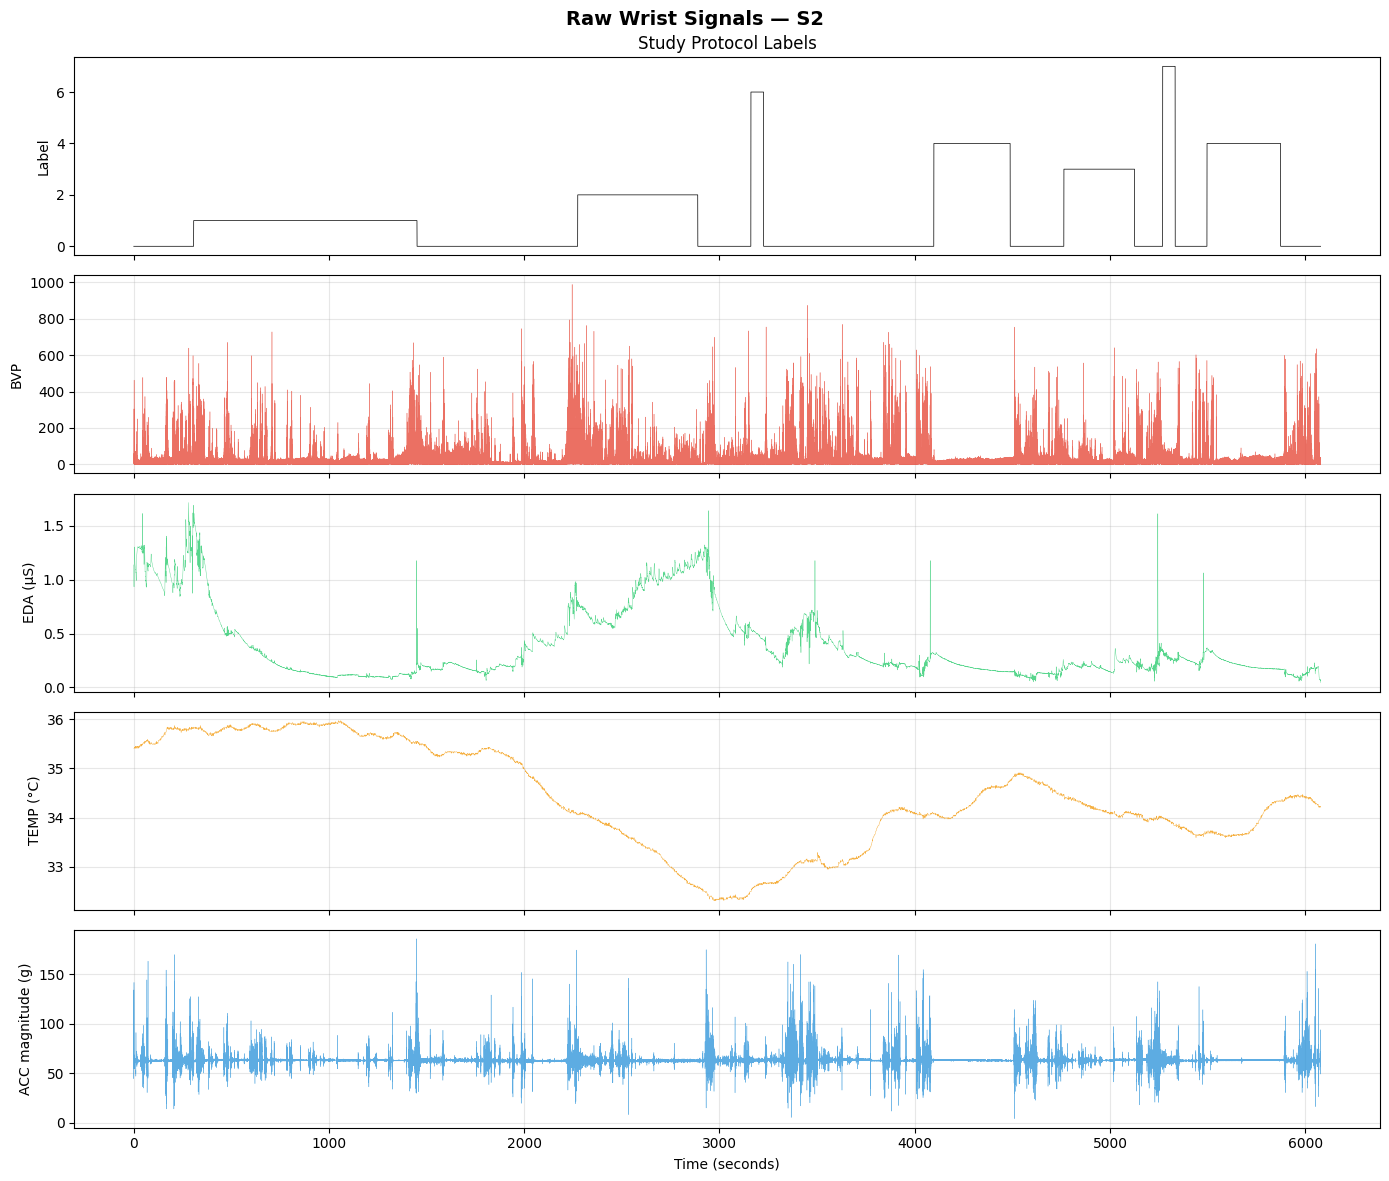

In [6]:
# === Visualize raw wrist signals for one subject ===
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"Raw Wrist Signals — S{SUBJECT_IDS[0]}", fontsize=14, fontweight='bold')

wrist = sample['signal']['wrist']
labels = sample['label'].flatten()

# Plot labels
t_labels = np.arange(len(labels)) / LABEL_SAMPLING_RATE
axes[0].plot(t_labels, labels, color='black', linewidth=0.5)
axes[0].set_ylabel('Label')
axes[0].set_title('Study Protocol Labels')

# Plot each wrist signal
signal_list = [
    ('BVP', 'BVP', '#e74c3c'),
    ('EDA', 'EDA (μS)', '#2ecc71'),
    ('TEMP', 'TEMP (°C)', '#f39c12'),
    ('ACC', 'ACC magnitude (g)', '#3498db'),
]

for i, (key, ylabel, color) in enumerate(signal_list):
    ax = axes[i + 1]
    sr = WRIST_SAMPLING_RATES[key]
    data = wrist[key]
    if data.ndim > 1:
        data = np.linalg.norm(data, axis=1)
    else:
        data = data.flatten()
    t = np.arange(len(data)) / sr
    ax.plot(t, data, color=color, linewidth=0.3, alpha=0.8)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()


## Section 3: Preprocessing & Windowing

Segment all wrist signals into **5-second** fixed windows. Each window gets a label via **majority vote** from the 700 Hz label stream. Windows with ambiguous labels (majority < 80%) or invalid labels (0, 4–7) are discarded.

Features are extracted at each signal's **native sampling rate** to preserve information.


In [7]:
# === Process all subjects ===
all_windows = {}
all_labels_dict = {}

for sid in SUBJECT_IDS:
    w, l = create_windows(all_subjects_data[sid], 5, LABEL_SAMPLING_RATE, WRIST_SAMPLING_RATES, VALID_LABELS)
    all_windows[sid] = w
    all_labels_dict[sid] = l
    unique, counts = np.unique(l, return_counts=True)
    dist = ", ".join([f"{LABEL_MAP[int(u)]}={c}" for u, c in zip(unique, counts)])
    print(f"S{sid}: {len(w)} windows ({dist})")

total = sum(len(v) for v in all_windows.values())
print(f"\nTotal windows: {total}")


S2: 422 windows (Baseline=228, Stress=122, Amusement=72)
S3: 428 windows (Baseline=227, Stress=127, Amusement=74)
S4: 431 windows (Baseline=231, Stress=126, Amusement=74)
S5: 441 windows (Baseline=239, Stress=128, Amusement=74)
S6: 439 windows (Baseline=235, Stress=130, Amusement=74)
S7: 438 windows (Baseline=237, Stress=127, Amusement=74)
S8: 439 windows (Baseline=233, Stress=133, Amusement=73)
S9: 438 windows (Baseline=236, Stress=128, Amusement=74)
S10: 453 windows (Baseline=235, Stress=144, Amusement=74)
S11: 444 windows (Baseline=236, Stress=135, Amusement=73)
S13: 444 windows (Baseline=235, Stress=133, Amusement=76)
S14: 444 windows (Baseline=235, Stress=135, Amusement=74)
S15: 445 windows (Baseline=235, Stress=137, Amusement=73)
S16: 442 windows (Baseline=235, Stress=134, Amusement=73)
S17: 453 windows (Baseline=235, Stress=144, Amusement=74)

Total windows: 6601


# Section 4 — Feature Extraction


For each 5-second window, extract **time-domain** and **frequency-domain** features from all wrist signals:
- **Statistical**: mean, std, min, max, median, range, skewness, kurtosis, RMS, mean absolute deviation, sum of absolute differences
- **Frequency**: total power, dominant frequency, spectral entropy (via Welch's method)
- **EDA-specific**: number of peaks, mean peak height, derivative statistics

In [12]:
# === Build the feature matrix ===
print("Extracting features from all windows...")

feature_rows = []
label_rows = []
group_rows = []

for sid in SUBJECT_IDS:
    n = len(all_windows[sid])
    print(f"  S{sid}: {n} windows...", end=" ")
    for window, label in zip(all_windows[sid], all_labels_dict[sid]):
        feature_rows.append(extract_window_features(window, WRIST_SAMPLING_RATES))
        label_rows.append(BINARY_MAP[label])
        group_rows.append(sid)
    print("done")

X = pd.DataFrame(feature_rows)
y = np.array(label_rows)
groups = np.array(group_rows)

# Clean NaN/Inf
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nFeature matrix: {X.shape[0]} samples × {X.shape[1]} features")
print(f"Non-Stress: {np.sum(y == 0)}, Stress: {np.sum(y == 1)}")
print(f"\nFeatures ({X.shape[1]}):")
for i, c in enumerate(X.columns, 1):
    print(f"  {i:3d}. {c}")


Extracting features from all windows...
  S2: 422 windows... done
  S3: 428 windows... done
  S4: 431 windows... done
  S5: 441 windows... done
  S6: 439 windows... done
  S7: 438 windows... done
  S8: 439 windows... done
  S9: 438 windows... done
  S10: 453 windows... done
  S11: 444 windows... done
  S13: 444 windows... done
  S14: 444 windows... done
  S15: 445 windows... done
  S16: 442 windows... done
  S17: 453 windows... done

Feature matrix: 6601 samples × 99 features
Non-Stress: 4618, Stress: 1983

Features (99):
    1. ACC_x_mean
    2. ACC_x_std
    3. ACC_x_min
    4. ACC_x_max
    5. ACC_x_median
    6. ACC_x_range
    7. ACC_x_skew
    8. ACC_x_kurtosis
    9. ACC_x_rms
   10. ACC_x_mad
   11. ACC_x_sad
   12. ACC_x_total_power
   13. ACC_x_dom_freq
   14. ACC_x_spectral_entropy
   15. ACC_y_mean
   16. ACC_y_std
   17. ACC_y_min
   18. ACC_y_max
   19. ACC_y_median
   20. ACC_y_range
   21. ACC_y_skew
   22. ACC_y_kurtosis
   23. ACC_y_rms
   24. ACC_y_mad
   25. ACC_y_s

# Section 5. Feature Analysis

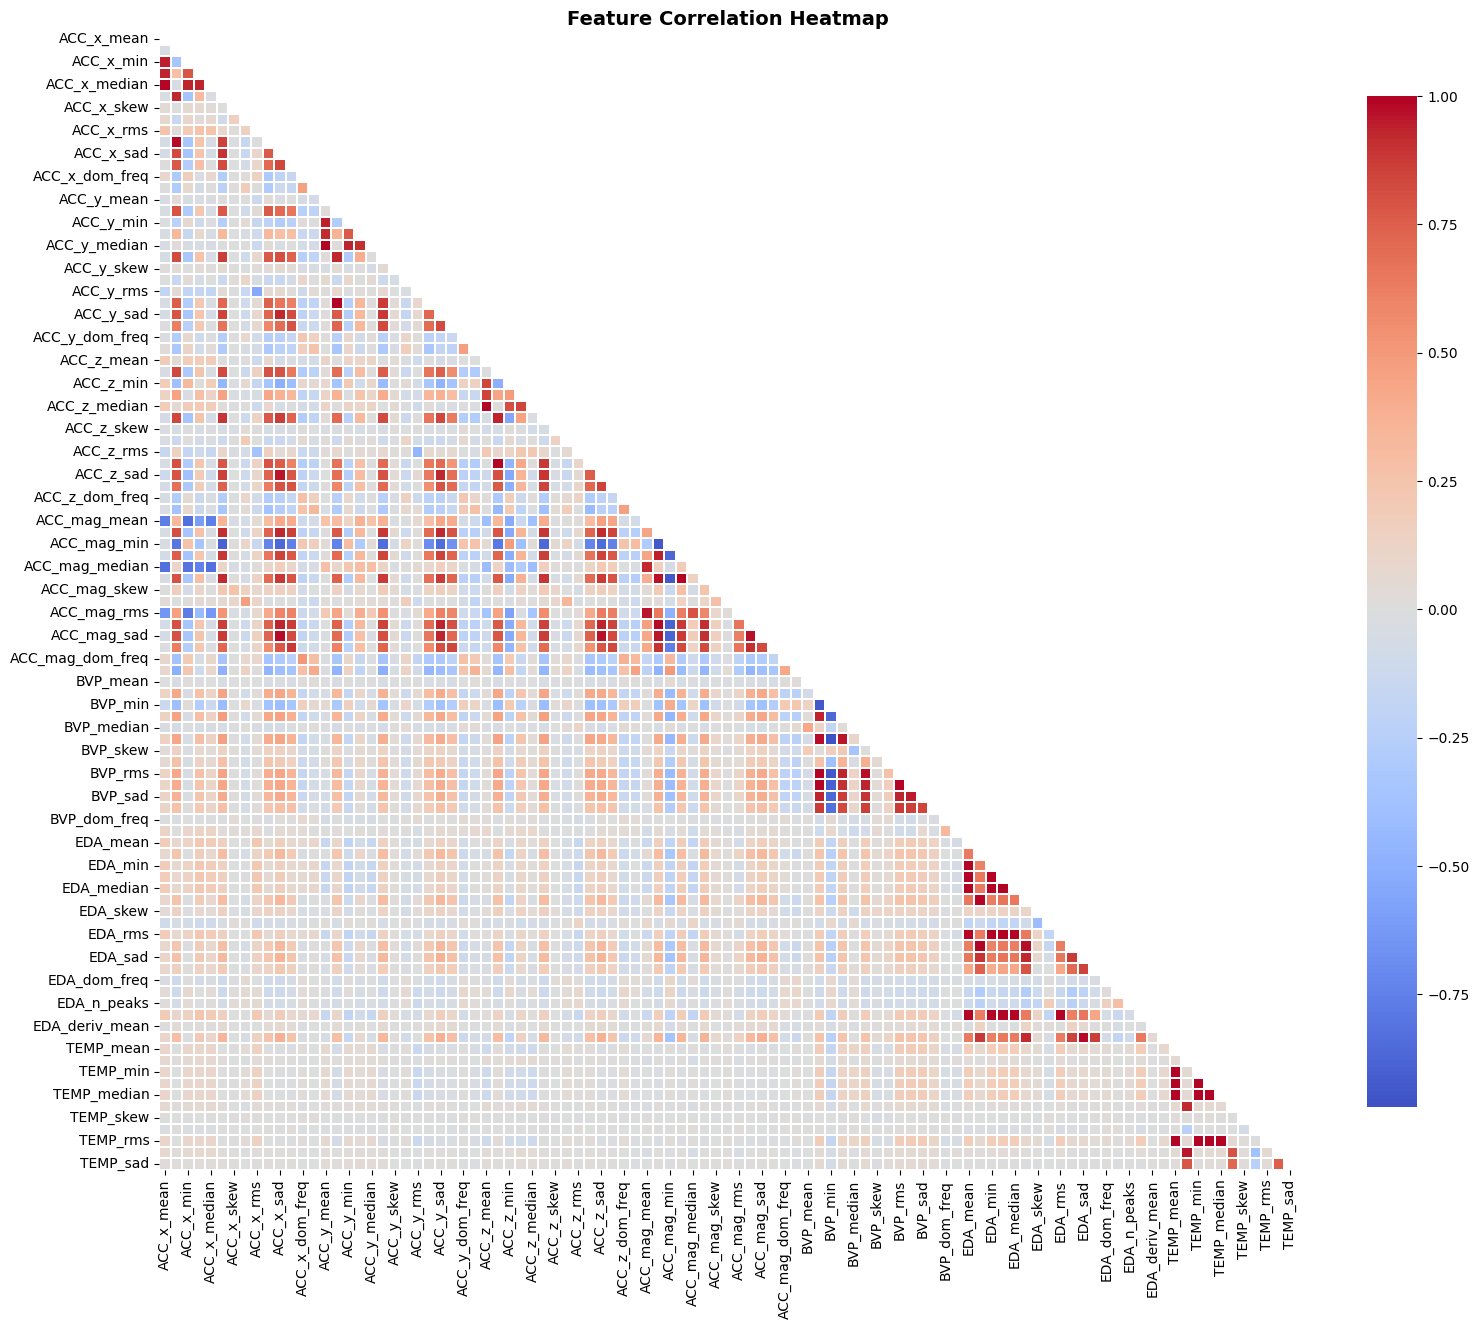

In [13]:
# === Correlation heatmap ===
plt.figure(figsize=(16, 14))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, annot=False,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


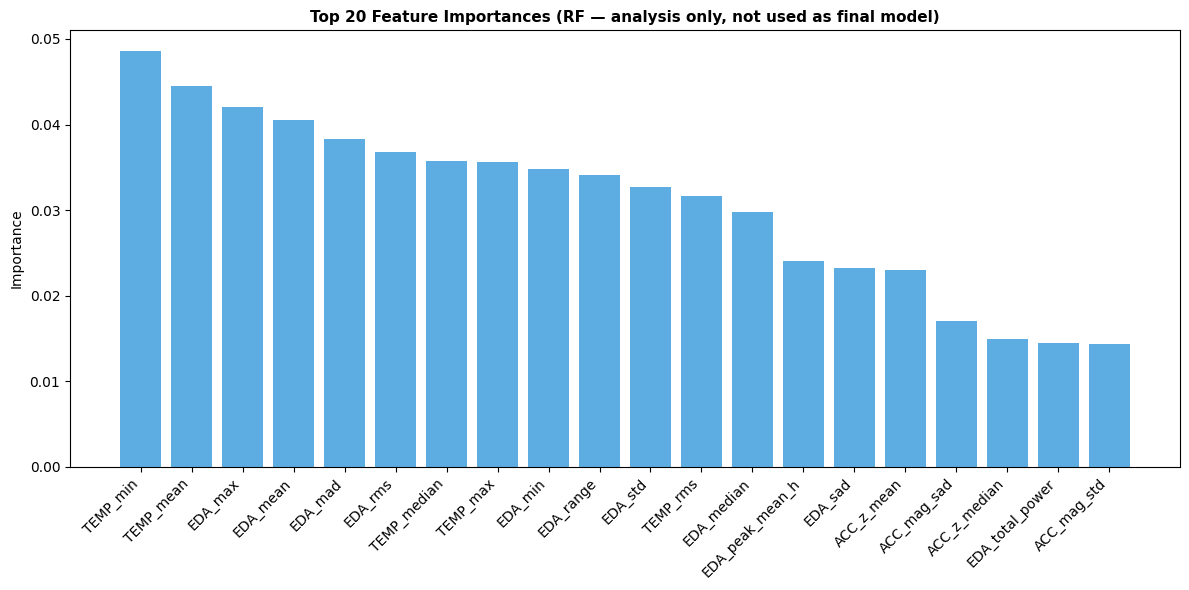

In [14]:
# === Feature importance (quick RF — for analysis only, not a final model) ===
scaler_tmp = StandardScaler()
X_tmp = scaler_tmp.fit_transform(X)

rf_analysis = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_analysis.fit(X_tmp, y)

importances = rf_analysis.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[top_idx], color='#3498db', alpha=0.8)
plt.xticks(range(20), [X.columns[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 Feature Importances (RF — analysis only, not used as final model)',
          fontsize=11, fontweight='bold')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()


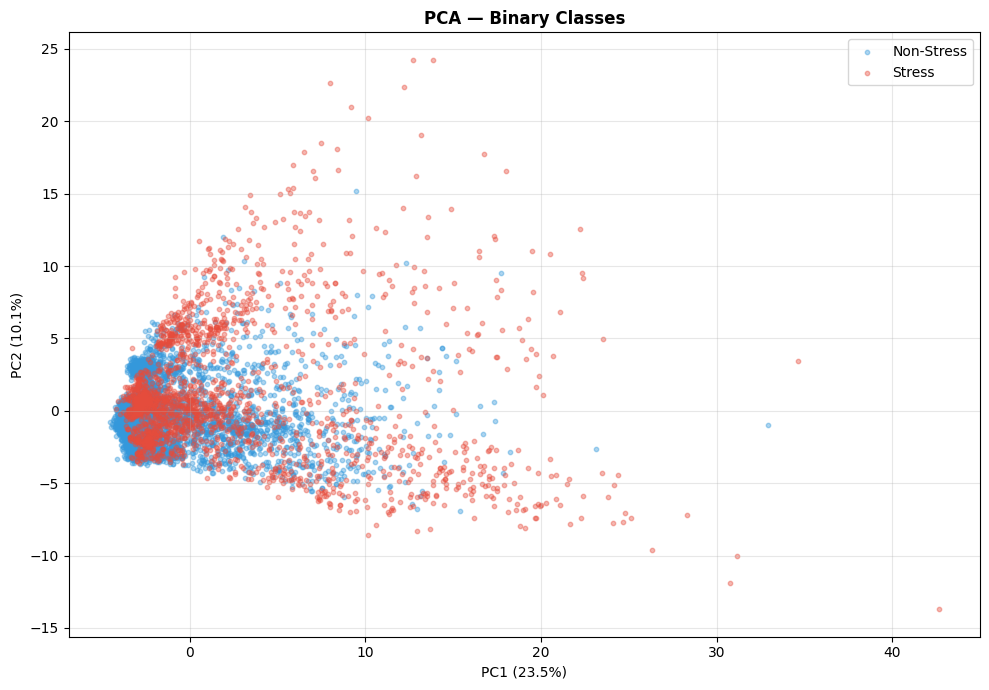

Explained variance (2 PCs): 33.6%


In [15]:
# === PCA Visualization ===
scaler_pca = StandardScaler()
X_pca_in = scaler_pca.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_in)

plt.figure(figsize=(10, 7))
for lv, color, name in zip([0, 1], ['#3498db', '#e74c3c'], BINARY_LABEL_NAMES):
    m = y == lv
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=color, label=name, alpha=0.4, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — Binary Classes', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Explained variance (2 PCs): {sum(pca.explained_variance_ratio_)*100:.1f}%")


# Section 6. Model Development

Models chosen to be **different from the original WESAD paper** (which used DT, RF, AdaBoost, LDA, kNN):
1. **Logistic Regression**
2. **SVM** (RBF kernel)
3. **Gradient Boosting** (sklearn)
4. **MLP** (Multi-Layer Perceptron)

Cross Validation employed for the models is: 

**Leave-One-Subject-Out**: train on 14 subjects, test on 1. Ensures subject-independent evaluation.

In [ ]:
# === Define models ===
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        early_stopping=True, validation_fraction=0.1, random_state=42
    ),
}


In [18]:

# === LOSO CV ===
logo = LeaveOneGroupOut()
results = {name: {'y_true': [], 'y_pred': [], 'y_prob': [], 'subjects': []}
           for name in models}

n_folds = logo.get_n_splits(X, y, groups)
print(f"Running LOSO Cross-Validation ({n_folds} folds)")
print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print("=" * 70)

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    test_subj = groups[test_idx[0]]
    print(f"\nFold {fold+1}/{n_folds}: test on S{test_subj} "
          f"(train={len(train_idx)}, test={len(test_idx)})")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    for mname, model in models.items():
        m = clone(model)
        m.fit(X_tr, y_train)
        preds = m.predict(X_te)
        probs = m.predict_proba(X_te)[:, 1]

        results[mname]['y_true'].extend(y_test)
        results[mname]['y_pred'].extend(preds)
        results[mname]['y_prob'].extend(probs)
        results[mname]['subjects'].extend([test_subj] * len(y_test))

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        print(f"  {mname}: Acc={acc:.3f}, F1={f1:.3f}")

print("\n" + "=" * 70)
print("LOSO Cross-Validation complete!")

Running LOSO Cross-Validation (15 folds)
Features: 99  |  Samples: 6601

Fold 1/15: test on S2 (train=6179, test=422)
  Logistic Regression: Acc=0.682, F1=0.069
  SVM (RBF): Acc=0.711, F1=0.103
  Gradient Boosting: Acc=0.751, F1=0.245
  MLP: Acc=0.723, F1=0.146

Fold 2/15: test on S3 (train=6173, test=428)
  Logistic Regression: Acc=0.769, F1=0.655
  SVM (RBF): Acc=0.766, F1=0.667
  Gradient Boosting: Acc=0.853, F1=0.789
  MLP: Acc=0.722, F1=0.645

Fold 3/15: test on S4 (train=6170, test=431)
  Logistic Regression: Acc=0.974, F1=0.954
  SVM (RBF): Acc=0.947, F1=0.900
  Gradient Boosting: Acc=0.972, F1=0.953
  MLP: Acc=0.986, F1=0.976

Fold 4/15: test on S5 (train=6160, test=441)
  Logistic Regression: Acc=0.896, F1=0.795
  SVM (RBF): Acc=0.882, F1=0.778
  Gradient Boosting: Acc=0.782, F1=0.455
  MLP: Acc=0.984, F1=0.972

Fold 5/15: test on S6 (train=6162, test=439)
  Logistic Regression: Acc=0.948, F1=0.910
  SVM (RBF): Acc=0.617, F1=0.288
  Gradient Boosting: Acc=0.672, F1=0.631
  MLP

# Section 7. Evaluation

In [19]:
# === Overall metrics ===
print("=" * 70)
print("OVERALL MODEL COMPARISON")
print("=" * 70)

comparison = []
for mname in models:
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_pred'])

    row = {
        'Model': mname,
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp), 4),
        'Recall': round(recall_score(yt, yp), 4),
        'F1-Score': round(f1_score(yt, yp), 4),
    }
    comparison.append(row)
    print(f"\n--- {mname} ---")
    print(classification_report(yt, yp, target_names=BINARY_LABEL_NAMES))

comp_df = pd.DataFrame(comparison)
print("\nSummary Table:")
print(comp_df.to_string(index=False))


OVERALL MODEL COMPARISON

--- Logistic Regression ---
              precision    recall  f1-score   support

  Non-Stress       0.86      0.91      0.88      4618
      Stress       0.75      0.65      0.69      1983

    accuracy                           0.83      6601
   macro avg       0.80      0.78      0.79      6601
weighted avg       0.82      0.83      0.82      6601


--- SVM (RBF) ---
              precision    recall  f1-score   support

  Non-Stress       0.83      0.85      0.84      4618
      Stress       0.63      0.60      0.61      1983

    accuracy                           0.77      6601
   macro avg       0.73      0.72      0.73      6601
weighted avg       0.77      0.77      0.77      6601


--- Gradient Boosting ---
              precision    recall  f1-score   support

  Non-Stress       0.82      0.88      0.85      4618
      Stress       0.67      0.56      0.61      1983

    accuracy                           0.78      6601
   macro avg       0.74     

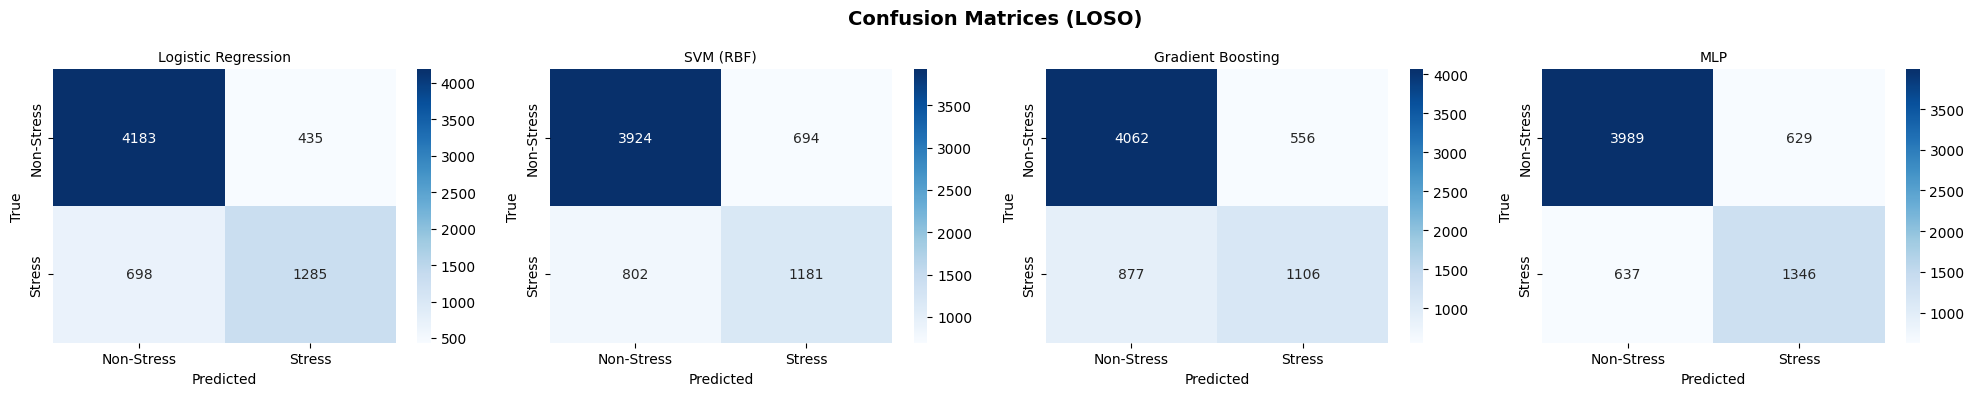

In [20]:
# === Confusion matrices ===
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
fig.suptitle('Confusion Matrices (LOSO)', fontsize=14, fontweight='bold')

for idx, mname in enumerate(models):
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_pred'])
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=BINARY_LABEL_NAMES, yticklabels=BINARY_LABEL_NAMES)
    axes[idx].set_title(mname, fontsize=10)
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


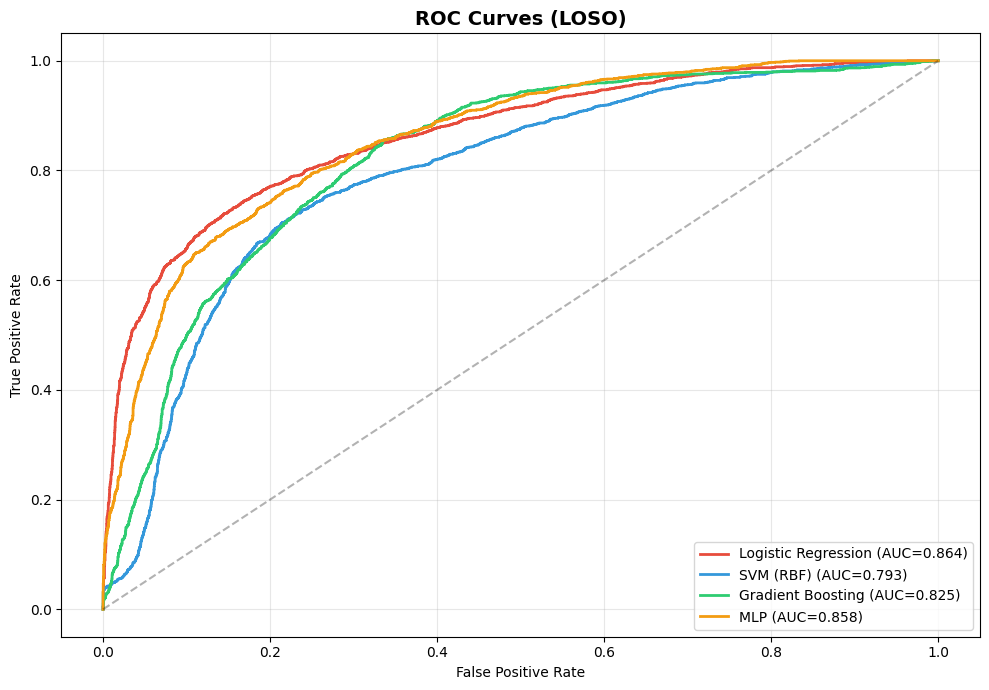

In [21]:
# === ROC Curves ===
plt.figure(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for mname, color in zip(models, colors):
    yt = np.array(results[mname]['y_true'])
    yp = np.array(results[mname]['y_prob'])
    fpr, tpr, _ = roc_curve(yt, yp)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{mname} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (LOSO)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Best model by F1: Logistic Regression

Subject  Accuracy     F1  N_samples  Stress_ratio
     S2    0.6825 0.0694        422         0.289
     S3    0.7687 0.6551        428         0.297
     S4    0.9745 0.9544        431         0.292
     S5    0.8957 0.7946        441         0.290
     S6    0.9476 0.9098        439         0.296
     S7    0.8333 0.7683        438         0.290
     S8    0.8360 0.6364        439         0.303
     S9    0.7306 0.1690        438         0.292
    S10    0.8344 0.6862        453         0.318
    S11    0.9257 0.8773        444         0.304
    S13    0.8311 0.7788        444         0.300
    S14    0.7995 0.5936        444         0.304
    S15    0.8270 0.7138        445         0.308
    S16    0.7805 0.7313        442         0.303
    S17    0.7550 0.4478        453         0.318


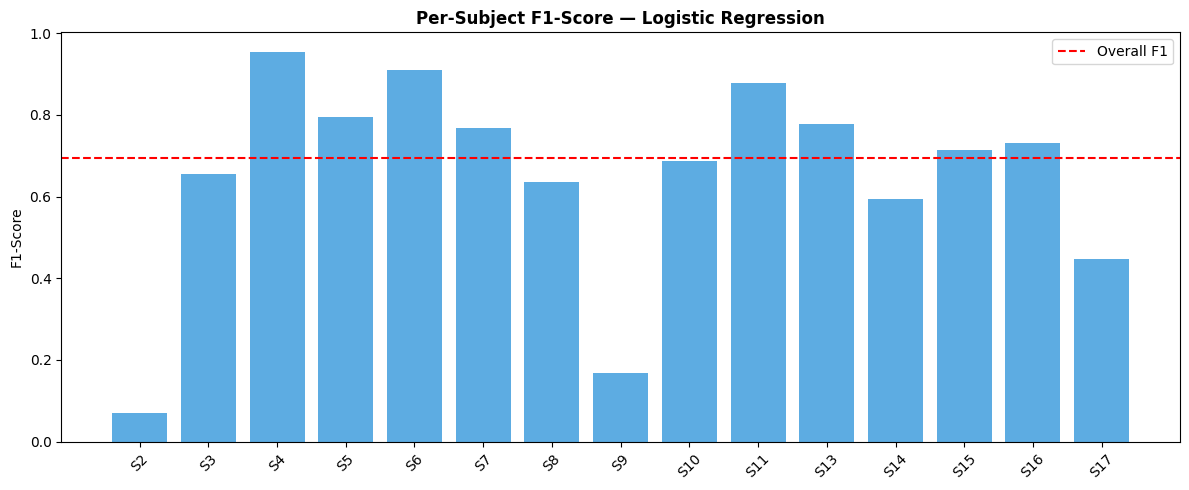

In [22]:
# === Per-subject performance (best model) ===
best_model = comp_df.loc[comp_df['F1-Score'].idxmax(), 'Model']
print(f"Best model by F1: {best_model}\n")

per_subj = []
for sid in SUBJECT_IDS:
    mask = np.array(results[best_model]['subjects']) == sid
    yt = np.array(results[best_model]['y_true'])[mask]
    yp = np.array(results[best_model]['y_pred'])[mask]
    per_subj.append({
        'Subject': f'S{sid}',
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'F1': round(f1_score(yt, yp, zero_division=0), 4),
        'N_samples': len(yt),
        'Stress_ratio': round(np.mean(yt), 3),
    })

per_subj_df = pd.DataFrame(per_subj)
print(per_subj_df.to_string(index=False))

# Plot per-subject F1
plt.figure(figsize=(12, 5))
plt.bar(per_subj_df['Subject'], per_subj_df['F1'], color='#3498db', alpha=0.8)
plt.axhline(y=comp_df.loc[comp_df['Model'] == best_model, 'F1-Score'].values[0],
            color='red', linestyle='--', label='Overall F1')
plt.ylabel('F1-Score')
plt.title(f'Per-Subject F1-Score — {best_model}', fontsize=12, fontweight='bold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


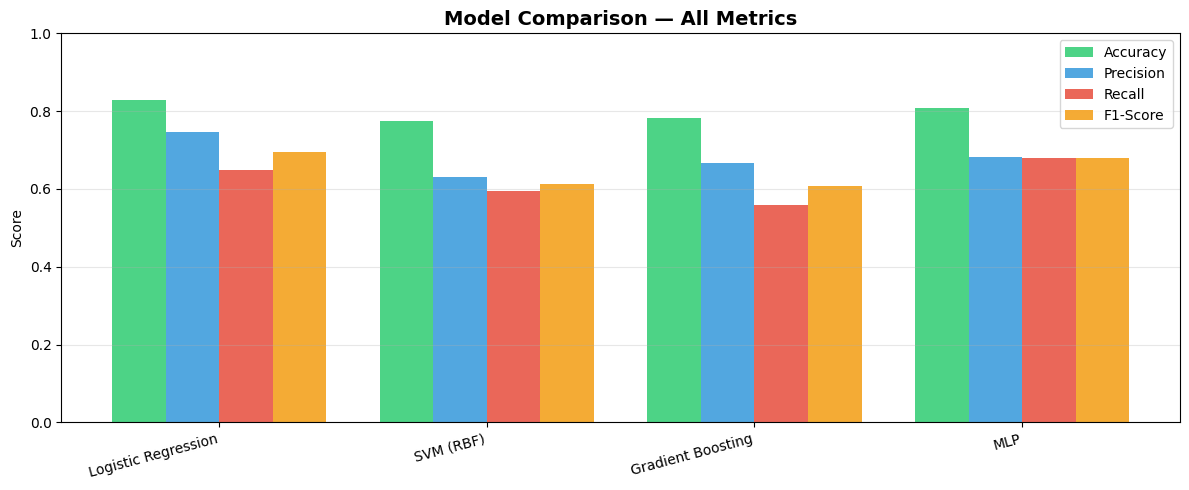

In [24]:
# === Final model comparison bar chart ===
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comp_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_bar = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i * width, comp_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Section 9 — Advanced AI / Extensions (Bonus)
Feature selection (e.g., mutual information, recursive feature elimination)
Personalization vs. general models discussion
Robustness to noise analysis
Potential deep learning approach (CNN on raw signals or LSTM)


Section 10 — SoA Analysis & Critical Discussion
State-of-the-art analysis
Data access & quality considerations
Explainability discussion
Ethical considerations & GDPR
Challenges of AI in healthcare
Journal club checklist integration